<div style="background: linear-gradient(135deg,rgb(65, 202, 179),rgb(201, 224, 96)); 
        color:rgb(0, 0, 0); 
        width: 100%; 
        height: 60px; 
        text-align: center; 
        font-weight: bold; 
        line-height: 60px; 
        margin: 2 px 0; 
        font-size: 44px; 
        border-radius: 10px; 
        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.3);">
    2048 Deep Reinforcement Learning
</div>

This notebook walks through a compact end-to-end run for the DQN agent: we configure the environment, launch a training session, visualise learning curves, and run a short evaluation sweep. Feel free to tweak the hyperparameters and rerun cells to explore different behaviours.

## Notebook roadmap
1. Configure utilities and hyperparameters.
2. Launch a short training loop while capturing metrics.
3. Visualise rewards, scores, and exploration decay.
4. Evaluate the trained policy over multiple games.

In [ ]:
from dataclasses import asdict
from pathlib import Path
from typing import Dict
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from game2048.agent import DQNAgent

# --- GPU memory growth (to avoid OOM) ---
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

# TensorFlow settings
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# --- Setup project path ---
PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / "game2048").exists():
    sys.path.insert(0, str(PROJECT_ROOT))
elif (PROJECT_ROOT.parent / "game2048").exists():
    sys.path.insert(0, str(PROJECT_ROOT.parent))

from game2048.train import TrainingConfig, run_training_session

# --- Plot style ---
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))

GPUs Available: 1


> ### **Helpers**

In [2]:
def ensure_run_dir(name: str = "default") -> Path:
    """Create (if missing) and return a directory inside Model/ for artifacts."""
    run_dir = Path.cwd() / "Model" / name
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir

def describe_history(history_df: pd.DataFrame) -> Dict[str, float]:
    """Compute a few headline metrics from the training history."""
    if history_df.empty:
        return {"episodes": 0, "mean_score": float("nan"), "max_tile": float("nan")}
    return {
        "episodes": int(history_df["episode"].max()),
        "mean_score": float(history_df["score"].mean()),
        "mean_reward": float(history_df["reward"].mean()),
        "mean_loss": float(history_df["loss"].mean(skipna=True)),
        "max_tile": float(history_df["max_tile"].max()),
    }

def plot_training_curves(history_df: pd.DataFrame, window: int = 5) -> None:
    if history_df.empty:
        print("History is empty. Increase the number of episodes or enable capture_history.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # --- Score curve ---
    rolling_score = history_df["score"].rolling(window=window, min_periods=1).mean()
    axes[0].plot(history_df["episode"], history_df["score"], color="#1f77b4", alpha=0.3, label="score")
    axes[0].plot(history_df["episode"], rolling_score, color="#1f77b4", label=f"score (rolling {window})")
    axes[0].set_title("Episode score")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Score")
    axes[0].legend()
    
    # --- Epsilon decay ---
    axes[1].plot(history_df["episode"], history_df["epsilon"], color="#d62728")
    axes[1].set_title("Exploration decay (epsilon)")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Epsilon")
    
    plt.tight_layout()
    plt.show()

> ### **Training session**

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent if "notebooks" in str(Path.cwd()) else Path.cwd().resolve()

run_name = PROJECT_ROOT / "Model" / "run-20250927-134259"
model_dir = ensure_run_dir(run_name)

config = TrainingConfig(
    episodes=200,
    max_steps_per_episode=400,
    batch_size=64,
    start_train_after=256,
    train_every=4,
    log_every=2,
    save_every=20,
    eval_every=0,
    invalid_move_penalty=1.0,
    target_tile_bonus=50.0,
    target_tile=2048,
    evaluation_episodes=5,
)
config.model_dir = str(model_dir)

print("Using model directory:", config.model_dir)
pd.DataFrame(sorted(asdict(config).items()), columns=["parameter", "value"])

Using model directory: D:\Data_Science\Porjects\2048-DeepRL\Model\run-20250927-134259


,parameter,value
0,batch_size,64
1,checkpoint_name,dqn_checkpoint.keras
2,early_stop_patience,5
3,episodes,200
4,eval_every,0
5,evaluation_episodes,5
6,invalid_move_penalty,1.0
7,log_every,2
8,max_steps_per_episode,400
9,model_dir,D:\Data_Science\Porjects\2048-DeepRL\Model\run...


In [ ]:
checkpoint = Path(config.model_dir) / config.checkpoint_name

if checkpoint.exists():
    print(f"Resuming from checkpoint: {checkpoint}")
    agent = DQNAgent(batch_size=config.batch_size, model_dir=config.model_dir)
    agent.load(str(checkpoint))
else:
    print("No checkpoint found, starting fresh...")
    agent = None

Resuming from checkpoint: D:\Data_Science\Porjects\2048-DeepRL\Model\run-20250927-134259\dqn_checkpoint.keras
Successfully loaded checkpoint from: D:\Data_Science\Porjects\2048-DeepRL\Model\run-20250927-134259\dqn_checkpoint.keras
Successfully loaded checkpoint from: D:\Data_Science\Porjects\2048-DeepRL\Model\run-20250927-134259\dqn_checkpoint.keras


In [5]:
%%time
agent, history, summary = run_training_session(
    config,
    agent=agent,
    persist_artifacts=True,
    capture_history=True,
)

Resuming training from checkpoint: D:\Data_Science\Porjects\2048-DeepRL\Model\run-20250927-134259\dqn_checkpoint.keras
Loaded 800 previous episodes from history
Episode   Score       Reward      Loss        Steps     Epsilon     Max tile  
802       516.0       500.0       n/a         86.0      0.9990      64.0      
Episode   Score       Reward      Loss        Steps     Epsilon     Max tile  
802       516.0       500.0       n/a         86.0      0.9990      64.0      
Episode   Score       Reward      Loss        Steps     Epsilon     Max tile  
804       1244.0      1221.0      6.9371      152.0     0.9976      128.0     
Episode   Score       Reward      Loss        Steps     Epsilon     Max tile  
804       1244.0      1221.0      6.9371      152.0     0.9976      128.0     
Episode   Score       Reward      Loss        Steps     Epsilon     Max tile  
806       1156.0      1139.0      7.0054      133.0     0.9961      128.0     
Episode   Score       Reward      Loss        Ste

### Checkpoint & Resume Logic

The training session now supports resuming from checkpoints:
- If a checkpoint exists in the model directory, the agent will load it and continue training
- Episode numbering continues from where it left off  
- Training history is preserved and appended to
- If no checkpoint exists, training starts fresh

**Note**: The cell above will automatically detect and load any existing checkpoint.

Episodes completed  : 1000
Best score          : 3044.0
Duration (min)      : 31.47


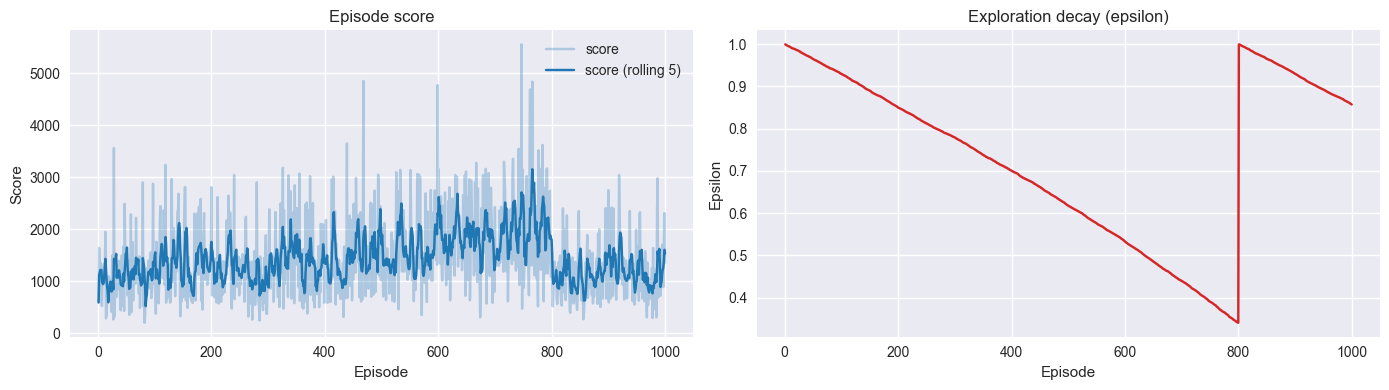

In [6]:
history_df = pd.DataFrame(history)  # type: ignore 
history_df.to_csv(model_dir / "history_append.csv", index=False)   # 👈 save to disk to avoid RAM issues

print(f"Episodes completed  : {len(history_df)}")
print(f"Best score          : {summary.best_score:.1f}")            # type: ignore 
print(f"Duration (min)      : {summary.duration_seconds/60:.2f}")   # type: ignore 
plot_training_curves(history_df)

In [7]:
summary_stats = describe_history(history_df) # type: ignore
pd.DataFrame([summary_stats])

,episodes,mean_score,mean_reward,mean_loss,max_tile
0,1000,1435.98,1415.891,9.558006,512.0
